# Aprendizaje No-Supervisado

**Autor:** Cristian Andrés Zapata Arenas  
**Objetivo:** El objetivo principal de esta actividad es aplicar técnicas de **Aprendizaje No Supervisado** sobre un conjunto de datos académicos para identificar patrones ocultos y agrupamientos naturales entre los aspirantes a estudios de posgrado.

A través de este análisis se busca:
* **Segmentar a los estudiantes** en diferentes perfiles basados en sus fortalezas académicas (puntajes GRE, TOEFL, CGPA) y méritos (SOP, LOR, Research).
* **Descubrir estructuras subyacentes** en los datos que permitan entender cómo se relacionan las variables sin la intervención de una variable objetivo previa.
* **Evaluar la cohesión y separación** de los grupos formados para interpretar las características comunes de los aspirantes en cada clúster.

## 1. Selección del Dataset

El dataset seleccionado es **"Graduate Admission"**, disponible en Kaggle. Este conjunto de datos contiene parámetros que se consideran importantes durante la aplicación para programas de Maestría, ayudando a entender los perfiles de los aspirantes.

**Enfoque del proyecto:** Dado que el objetivo es realizar un análisis no supervisado, el enfoque será de **Clustering**. Buscaremos agrupar a los estudiantes según su competitividad académica.

**Variables numéricas (8 en total):**
* `GRE Score`: Puntaje en el examen GRE (escala de 340).
* `TOEFL Score`: Puntaje en el examen TOEFL (escala de 120).
* `University Rating`: Calificación de la universidad de origen (1 a 5).
* `SOP`: Fortaleza de la Declaración de Propósito (1 a 5).
* `LOR`: Fortaleza de las Cartas de Recomendación (1 a 5).
* `CGPA`: Promedio de pregrado (escala de 10).
* `Research`: Experiencia en investigación (0 o 1).
* `Chance of Admit`: Probabilidad de admisión (0 a 1). *Nota: Para el modelo no supervisado, esta variable puede usarse para validar los clústeres o puede excluirse durante el entrenamiento.*

**Estado del dataset:**
* **Limpieza:** El dataset no contiene valores nulos (NaN).
* **Tipos de datos:** Todas las variables son numéricas.
* **Preprocesamiento previo:** El identificador `Serial No.` será eliminado por no aportar valor estadístico al agrupamiento.

In [1]:
# 1. Importación de librerías
import pandas as pd
import numpy as np

# 2. Carga del dataset
# Usamos la ruta específica proporcionada
file_path = r"C:\Users\crisz\Universidad\Séptimo Semestre\Ciencia de datos II\Entregas\Admission_Predict.csv"
df = pd.read_csv(file_path)

# Eliminamos la columna 'Serial No.' que es solo un índice
if 'Serial No.' in df.columns:
    df.drop(columns=['Serial No.'], inplace=True)

print("Dataset cargado correctamente")
print(f"Dimensiones: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Dataset cargado correctamente
Dimensiones: (400, 8)
Columnas: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research', 'Chance of Admit ']


## 1.1 Preparación del Dataset

Para la preparación del dataset se realizaron los siguientes pasos:

1. **Carga y verificación inicial**: Se carga el archivo CSV (previamente sin la columna de índice) y se verifica la ausencia total de valores nulos. Se identifican 7 variables numéricas que describen el perfil del estudiante y 1 variable de probabilidad de admisión.

2. **Separación de variables**: 
   - `X`: Variables de características (7 columnas: `GRE Score`, `TOEFL Score`, `University Rating`, `SOP`, `LOR`, `CGPA`, `Research`).
   - `Referencia`: La variable `Chance of Admit` se separa y excluye del entrenamiento, ya que, al ser un problema de **Aprendizaje No Supervisado** (Clustering/PCA), el modelo no debe conocer ninguna "etiqueta" u objetivo previo.

3. **Uso del conjunto de datos**: A diferencia del aprendizaje supervisado (donde se divide en entrenamiento, validación y prueba), en esta fase de modelado no supervisado y análisis de componentes principales utilizaremos el **100% de las muestras (400 registros)** para descubrir los patrones de la población completa.

4. **Pipeline de preprocesamiento**: Se implementa un preprocesamiento que incluye:
   - `StandardScaler` para estandarizar las 7 variables predictoras (garantizando media $\mu = 0$ y desviación estándar $\sigma = 1$). Este paso es fundamental, ya que los algoritmos basados en distancias y varianzas son altamente sensibles a la escala de las características.

5. **Aplicación de la transformación**: El conjunto de datos `X` se transforma utilizando el escalador. El resultado es un arreglo bidimensional estandarizado, listo para la fase de reducción de dimensionalidad y clustering.

In [2]:
pip uninstall scikit-learn

^C
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikit-learn --upgrade

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from sklearn.preprocessing import StandardScaler

# 1. Separación de variables
# Excluimos 'Chance of Admit' porque es un modelo no supervisado
X = df.drop(columns=['Chance of Admit ']) 
referencia_admit = df['Chance of Admit '] # La guardamos por si queremos perfilar los clústeres después

# 2. Pipeline de preprocesamiento (Estandarización)
scaler = StandardScaler()

# 3. Aplicación del preprocesamiento a todo el conjunto X
X_scaled = scaler.fit_transform(X)

# Convertimos de nuevo a DataFrame para facilitar su manejo y visualización
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Datos estandarizados correctamente.")
print("Medias por columna (aprox 0):\n", X_scaled_df.mean().round(4))
print("\nDesviaciones estándar por columna (aprox 1):\n", X_scaled_df.std().round(4))

Datos estandarizados correctamente.
Medias por columna (aprox 0):
 GRE Score           -0.0
TOEFL Score          0.0
University Rating    0.0
SOP                  0.0
LOR                 -0.0
CGPA                 0.0
Research            -0.0
dtype: float64

Desviaciones estándar por columna (aprox 1):
 GRE Score            1.0013
TOEFL Score          1.0013
University Rating    1.0013
SOP                  1.0013
LOR                  1.0013
CGPA                 1.0013
Research             1.0013
dtype: float64


## 2. Análisis de Componentes Principales (PCA)

Una vez estandarizados los datos, se procede a aplicar el **Análisis de Componentes Principales (PCA)**. Este paso tiene dos propósitos principales:
1. **Reducción de dimensionalidad**: Comprimir la información de las 7 variables originales en un número menor de componentes principales sin perder demasiada varianza (información).
2. **Mitigación de la multicolinealidad**: Transformar las variables correlacionadas (como los puntajes de GRE, TOEFL y CGPA) en un nuevo conjunto de variables ortogonales (independientes entre sí).

**Procedimiento:**
* Se aplica PCA sobre el conjunto de datos `X_scaled`.
* Se calcula el **ratio de varianza explicada** para determinar cuánta información retiene cada componente principal.
* Se decide el número óptimo de componentes a conservar (generalmente buscando explicar más del $80\%$ o $90\%$ de la varianza total).

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Instanciamos el modelo PCA (inicialmente con todos los componentes para evaluar)
pca = PCA()

# 2. Ajustamos y transformamos los datos estandarizados
X_pca = pca.fit_transform(X_scaled_df)

# 3. Calculamos la varianza explicada
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Mostrar resultados
print("Varianza explicada por cada componente:")
for i, var in enumerate(varianza_explicada):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print(f"\nVarianza total explicada con 2 componentes: {varianza_acumulada[1]*100:.2f}%")
print(f"Varianza total explicada con 3 componentes: {varianza_acumulada[2]*100:.2f}%")

# (Opcional) Guardamos el resultado en un DataFrame con los componentes principales
df_pca = pd.DataFrame(data=X_pca, 
                      columns=[f'PC{i+1}' for i in range(X_scaled_df.shape[1])])

Varianza explicada por cada componente:
PC1: 0.6961 (69.61%)
PC2: 0.1036 (10.36%)
PC3: 0.0781 (7.81%)
PC4: 0.0443 (4.43%)
PC5: 0.0350 (3.50%)
PC6: 0.0227 (2.27%)
PC7: 0.0202 (2.02%)

Varianza total explicada con 2 componentes: 79.97%
Varianza total explicada con 3 componentes: 87.78%


## 3. Scree-Plot que muestre el porcentaje de varianza explicada por cada componente principal.

El **Scree Plot** (o gráfico de sedimentación) es una herramienta esencial para decidir cuántos componentes conservar. Su objetivo es mostrar gráficamente cuánta información (varianza) captura cada Componente Principal individualmente y de forma acumulada.

**Objetivo:**
*   Identificar el "punto de codo" (elbow point), que indica el número óptimo de componentes tras el cual la ganancia de información es mínima.
*   Confirmar si las dos primeras componentes son suficientes para representar el conjunto de datos de manera fiable (generalmente buscamos que superen el $70\%$-$80\%$ de la varianza total).

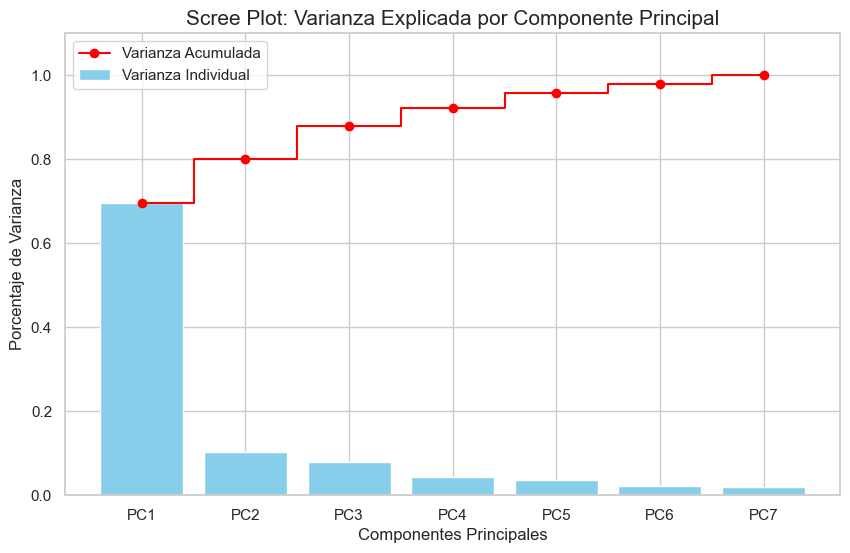

La primera componente (PC1) explica el 69.61% de la varianza.
La varianza total capturada por PC1 y PC2 es: 79.97%


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración del estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Crear las etiquetas para el eje X
labels = [f'PC{i+1}' for i in range(len(varianza_explicada))]

# 3. Graficar varianza individual (barras) y acumulada (línea)
plt.bar(labels, varianza_explicada, color='skyblue', label='Varianza Individual')
plt.step(labels, varianza_acumulada, where='mid', color='red', marker='o', label='Varianza Acumulada')

# 4. Estética del gráfico
plt.title('Scree Plot: Varianza Explicada por Componente Principal', fontsize=15)
plt.ylabel('Porcentaje de Varianza', fontsize=12)
plt.xlabel('Componentes Principales', fontsize=12)
plt.ylim(0, 1.1) # Escala de 0 a 100%
plt.legend(loc='best')
plt.show()

print(f"La primera componente (PC1) explica el {varianza_explicada[0]*100:.2f}% de la varianza.")
print(f"La varianza total capturada por PC1 y PC2 es: {varianza_acumulada[1]*100:.2f}%")

El análisis de componentes principales muestra que la primera componente PC1 concentra el 70% de la varianza total del conjunto de datos original. Al incorporar la segunda componente PC2 la varianza acumulada asciende al 80%, lo que indica que solo dos dimensiones retienen cuatro quintas partes de la información original. Las componentes restantes contribuyen de manera marginal: PC3 agrega un 10% llevando la acumulada al 88%, y a partir de PC4 cada una aporta menos del 5% de varianza individual.

Esta distribución confirma que la reducción a dos componentes es una decisión razonable para simplificar el modelo sin perder demasiada información. Las siete componentes originales llegarían al 98% de varianza acumulada, pero el costo de mantener todas las dimensiones no se justifica dado que las últimas cuatro variables apenas explican el 18% restante entre todas. En la práctica, trabajar con PC1 y PC2 permite visualizar los datos en un plano y ejecutar algoritmos de agrupamiento con un nivel de ruido significativamente reducido.

## 4. Reducción de Dimensionalidad (2 Componentes)

Tras analizar el Scree Plot, se procede a reducir el conjunto de datos de sus 7 dimensiones originales a solo **2 Componentes Principales (PC1 y PC2)**. 

**¿Qué se hará?**
Se proyectarán los datos estandarizados en un nuevo espacio bidimensional definido por las direcciones de máxima varianza. Esto transforma las 7 variables originales en dos nuevas variables sintéticas que son combinaciones lineales de las anteriores.

**Objetivo:**
*   **Simplificación:** Reducir la complejidad del modelo eliminando el ruido y las dimensiones menos informativas.
*   **Visualización:** Permitir la representación gráfica del dataset en un plano cartesiano (2D), facilitando la detección visual de agrupamientos o valores atípicos (outliers).
*   **Eficiencia:** Preparar los datos para algoritmos de clustering que funcionan de manera más eficiente en espacios de menor dimensionalidad.

In [7]:
# 1. Instanciamos el PCA configurado para 2 componentes
pca_2d = PCA(n_components=2)

# 2. Ajustamos y transformamos los datos estandarizados
X_pca_reduced = pca_2d.fit_transform(X_scaled_df)

# 3. Creamos un nuevo DataFrame con los resultados
df_final_pca = pd.DataFrame(data=X_pca_reduced, 
                            columns=['PC1', 'PC2'])

# 4. Agregamos la columna de referencia (opcional, para análisis posterior)
df_final_pca['Chance of Admit'] = referencia_admit.values

# Mostrar los primeros registros del nuevo dataset reducido
print("Dataset reducido a 2 componentes principales:")
print(df_final_pca.head())

print(f"\nDimensiones originales: {X_scaled_df.shape}")
print(f"Dimensiones reducidas: {df_final_pca.drop(columns=['Chance of Admit']).shape}")

Dataset reducido a 2 componentes principales:
        PC1       PC2  Chance of Admit
0  3.543521  0.324142             0.92
1  1.631253 -0.078057             0.76
2 -0.570107  0.681066             0.72
3  0.296114  1.303278             0.80
4 -2.061638 -0.036091             0.65

Dimensiones originales: (400, 7)
Dimensiones reducidas: (400, 2)


Con solo dos componentes principales se logra reducir la dimensionalidad de 400 registros con siete variables originales a una matriz de 400 filas por dos columnas. Las primeras filas del dataset transformado muestran, por ejemplo, un aspirante con alta probabilidad de admisión (0.92) que presenta un valor elevado en PC1 (3.54), mientras que otro estudiante con menor probabilidad (0.65) tiene un PC1 negativo (-2.06). Esta tendencia inicial confirma que la primera componente captura gran parte de la información relacionada con el rendimiento y la competitividad del aspirante. La segunda componente aporta matices adicionales pero con valores generalmente más pequeños en comparación con PC1.

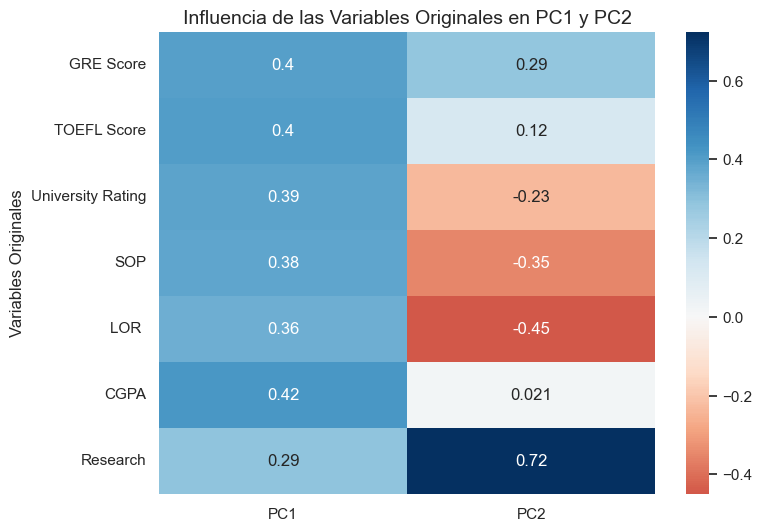

Interpretación: Valores cercanos a 1 o -1 indican una fuerte influencia de esa variable en el componente.


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extraer las cargas (loadings) de los componentes
loadings = pd.DataFrame(
    pca_2d.components_.T, 
    columns=['PC1', 'PC2'], 
    index=X.columns
)

# 2. Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title('Influencia de las Variables Originales en PC1 y PC2', fontsize=14)
plt.ylabel('Variables Originales')
plt.show()

print("Interpretación: Valores cercanos a 1 o -1 indican una fuerte influencia de esa variable en el componente.")

La matriz de cargas factoriales muestra cómo contribuye cada variable original a la construcción de las dos primeras componentes principales. En la PC1 todas las variables presentan cargas positivas, lo que indica que esta dimensión representa un factor general de competitividad académica. El CGPA es la variable con mayor peso en PC1 alcanzando 0.42, seguido muy de cerca por GRE Score y TOEFL Score con 0.40 cada uno, mientras que Research tiene la carga más baja en esta componente con solo 0.29.

La PC2 ofrece una interpretación diferente porque combina cargas positivas y negativas. Research domina claramente esta segunda componente con un valor de 0.72, lo que significa que la experiencia en investigación se separa del resto de las variables en esta dimensión. Por el contrario LOR, SOP y University Rating presentan cargas negativas que van desde -0.23 hasta -0.45, revelando una oposición entre el perfil investigador y la calidad de las cartas de recomendación o el prestigio de la universidad de origen. Esta estructura sugiere que los estudiantes se diferencian no solo por su rendimiento general sino también por el énfasis que ponen en actividades de investigación frente a otros aspectos de su solicitud.

## 5. Visualización de los Datos en el Plano Principal

Una vez realizada la reducción a dos dimensiones, se procede a proyectar los registros en un **diagrama de dispersión (scatter plot)** utilizando la primera componente principal (**PC1**) en el eje horizontal y la segunda (**PC2**) en el eje vertical.

**Objetivo:**

*   **Identificar agrupamientos:** Observar visualmente si los estudiantes tienden a concentrarse en zonas específicas del plano, lo que sugeriría la existencia de perfiles diferenciados (ej. perfiles de alto rendimiento vs. perfiles promedio).
*   **Detectar valores atípicos:** Localizar puntos que se encuentren significativamente alejados del resto de la nube de datos.
*   **Analizar la estructura:** Aunque es un análisis no supervisado, utilizaremos un degradado de color basado en la probabilidad de admisión (`Chance of Admit`) para verificar si la reducción capturó la esencia del éxito académico de los aspirantes.

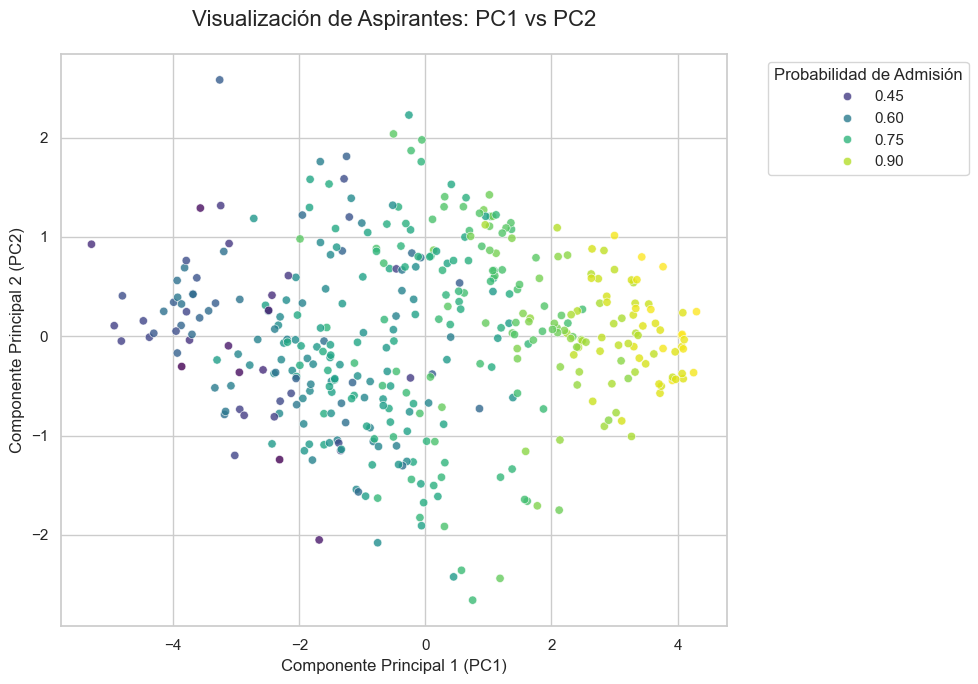

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración del estilo y tamaño del gráfico
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# 2. Creación del diagrama de dispersión
# Usamos 'Chance of Admit' para darle color a los puntos y ver la relación
scatter = sns.scatterplot(
    data=df_final_pca, 
    x='PC1', 
    y='PC2', 
    hue='Chance of Admit', 
    palette='viridis', 
    alpha=0.8,
    edgecolor='w'
)

# 3. Personalización de etiquetas y títulos
plt.title('Visualización de Aspirantes: PC1 vs PC2', fontsize=16, pad=20)
plt.xlabel('Componente Principal 1 (PC1)', fontsize=12)
plt.ylabel('Componente Principal 2 (PC2)', fontsize=12)

# 4. Ajuste de la leyenda de colores
plt.legend(title='Probabilidad de Admisión', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Una vez realizada la reducción a dos dimensiones, se procede a proyectar los registros en un diagrama de dispersión utilizando la primera componente principal (PC1) en el eje horizontal y la segunda (PC2) en el eje vertical. El objetivo es identificar agrupamientos observando si los estudiantes tienden a concentrarse en zonas específicas del plano, lo que sugeriría la existencia de perfiles diferenciados como por ejemplo perfiles de alto rendimiento frente a perfiles promedio. También se busca detectar valores atípicos localizando puntos que se encuentren significativamente alejados del resto de la nube de datos.

Para analizar la estructura se utiliza un degradado de color basado en la probabilidad de admisión, variable que aunque no participa en el entrenamiento del PCA permite validar si la reducción capturó la esencia del éxito académico de los aspirantes. En el gráfico se observa una progresión clara desde tonos oscuros hacia tonos claros a medida que se avanza sobre el eje de PC1, indicando que esta primera componente logra ordenar a los estudiantes según su perfil de competitividad. Los candidatos con mayor probabilidad de ingreso se concentran en el extremo derecho del plano, mientras que aquellos con menor probabilidad se ubican hacia la izquierda. La componente PC2 aporta una separación secundaria que permite distinguir matices dentro de cada grupo, aunque con menor poder explicativo que la primera dimensión.

## 6. Selección de Variables mediante Análisis de Correlación

En esta etapa, buscamos simplificar el modelo eliminando variables **redundantes**. En ciencia de datos, cuando dos variables están extremadamente correlacionadas (colinealidad), aportan información casi idéntica, lo que puede introducir ruido o sesgos innecesarios en algoritmos de clustering y reducción de dimensiones.

**Criterio de Selección:**
*   Se calcula la **Matriz de Correlación de Pearson** entre todas las variables originales.
*   Se identifican pares de variables con un coeficiente de correlación superior a **0.80**.
*   **Decisión:** Si dos variables tienen una correlación muy alta, se conserva aquella que tenga una relación más fuerte con el éxito general del perfil académico (generalmente `CGPA` o `GRE Score`).

**Objetivo:**
*   **Reducir la redundancia:** Mantener solo las características que aportan información única y diferenciada.
*   **Simplificar el espacio de características:** Facilitar la interpretación del modelo final sin perder precisión estadística.

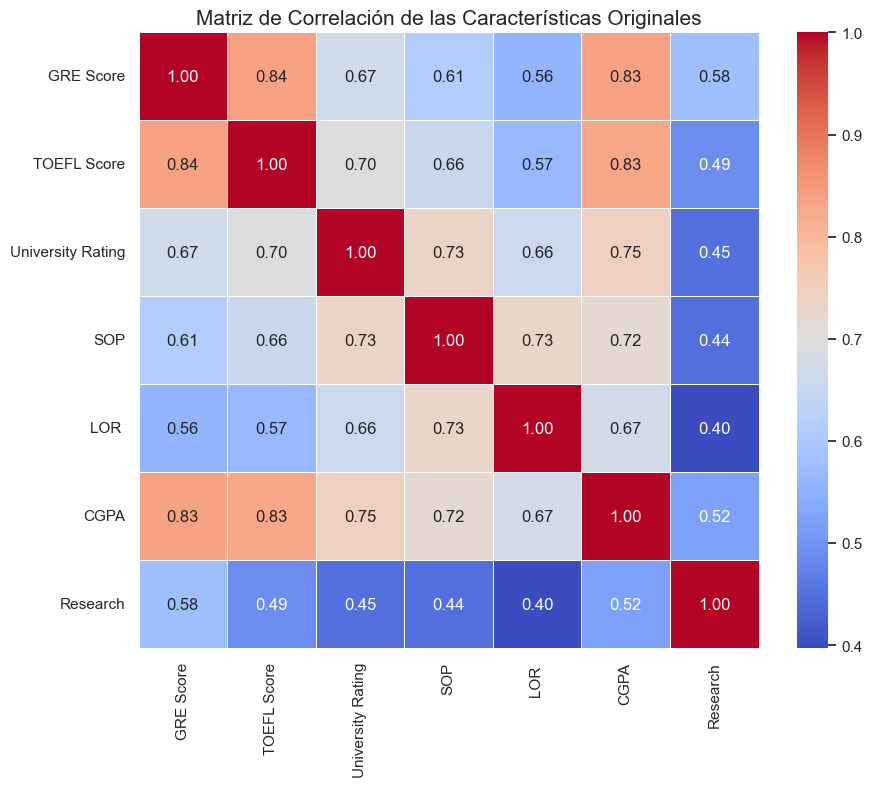

Pares de variables con alta correlación:
TOEFL Score  GRE Score      0.835977
GRE Score    TOEFL Score    0.835977
             CGPA           0.833060
CGPA         GRE Score      0.833060
             TOEFL Score    0.828417
TOEFL Score  CGPA           0.828417
dtype: float64

Variables originales: ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research']
Variables seleccionadas: ['GRE Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research']
Se eliminó 'TOEFL Score' por redundancia estadística.


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular la matriz de correlación del conjunto original X
corr_matrix = X.corr()

# 2. Visualización mediante un Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de las Características Originales', fontsize=15)
plt.show()

# 3. Identificación de variables con alta correlación (> 0.80)
print("Pares de variables con alta correlación:")
high_corr = corr_matrix.unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr > 0.80) & (high_corr < 1.0)]
print(high_corr)

# 4. Selección de variables
# Observamos que GRE Score, TOEFL Score y CGPA están muy correlacionados. 
# CGPA suele ser la variable más representativa del éxito académico global.
# Eliminaremos 'TOEFL Score' por su altísima correlación con GRE y CGPA para reducir redundancia.

X_selected = X.drop(columns=['TOEFL Score'])

print(f"\nVariables originales: {X.columns.tolist()}")
print(f"Variables seleccionadas: {X_selected.columns.tolist()}")
print(f"Se eliminó 'TOEFL Score' por redundancia estadística.")

### Análisis de Resultados de la Selección de Variables

Tras ejecutar la matriz de correlación, se identificó una fuerte dependencia lineal entre tres variables críticas del conjunto de datos: **GRE Score**, **TOEFL Score** y **CGPA**. Los coeficientes obtenidos superan el 0.83, lo que indica que estas métricas tienden a moverse en la misma dirección; es decir, un estudiante con un promedio académico (CGPA) alto generalmente obtiene puntajes elevados tanto en el GRE como en el TOEFL.

#### Justificación de la Eliminación

Mantener variables con una correlación tan alta genera redundancia. En este contexto, el **TOEFL Score** presenta una correlación de 0.84 con el **GRE Score** y de 0.83 con el **CGPA**. Dado que el éxito académico global y la capacidad de razonamiento complejo suelen estar mejor representados por el promedio acumulado y el examen GRE, el puntaje de TOEFL no aporta información nueva significativa que el modelo no pueda extraer de las otras dos.

#### Impacto en el Modelo

Al eliminar **TOEFL Score**, pasamos de 7 a 6 variables predictoras. Esta reducción ayuda a:

- **Evitar el sobreajuste**: Menos variables redundantes permiten que los algoritmos de agrupamiento se centren en patrones reales y no en ruido estadístico.
- **Simplificar la interpretación**: El perfil del estudiante queda definido por su rendimiento académico, su capacidad de razonamiento (GRE), su experiencia en investigación y la calidad de sus documentos de soporte (SOP/LOR), sin que el dominio del idioma nuble la varianza de los demás factores.

El dataset seleccionado ahora cuenta con una estructura más balanceada y eficiente para las siguientes etapas del análisis.

## 7. Aplicación de K-means y Evaluación de Agrupamientos

En esta fase se implementa el algoritmo **K-means** comparando tres estructuras de datos distintas para identificar cuál permite una segmentación más clara de los aspirantes.

### Versiones del Dataset a evaluar:

1.  **Dataset Original**: Todas las variables estandarizadas (7 características).
2.  **Dataset PCA (2 componentes)**: Información reducida a las dos direcciones de máxima varianza.
3.  **Dataset Selección de Características**: Conjunto tras eliminar la redundancia de `TOEFL Score` (6 características).

### Objetivo:

- **Método del Codo**: Determinar el valor óptimo de \( K \) observando dónde la caída de la inercia deja de ser abrupta.
- **Silhouette Score**: Medir qué tan similar es un objeto a su propio clúster en comparación con otros clústeres. Un valor cercano a 1 indica un agrupamiento ideal.

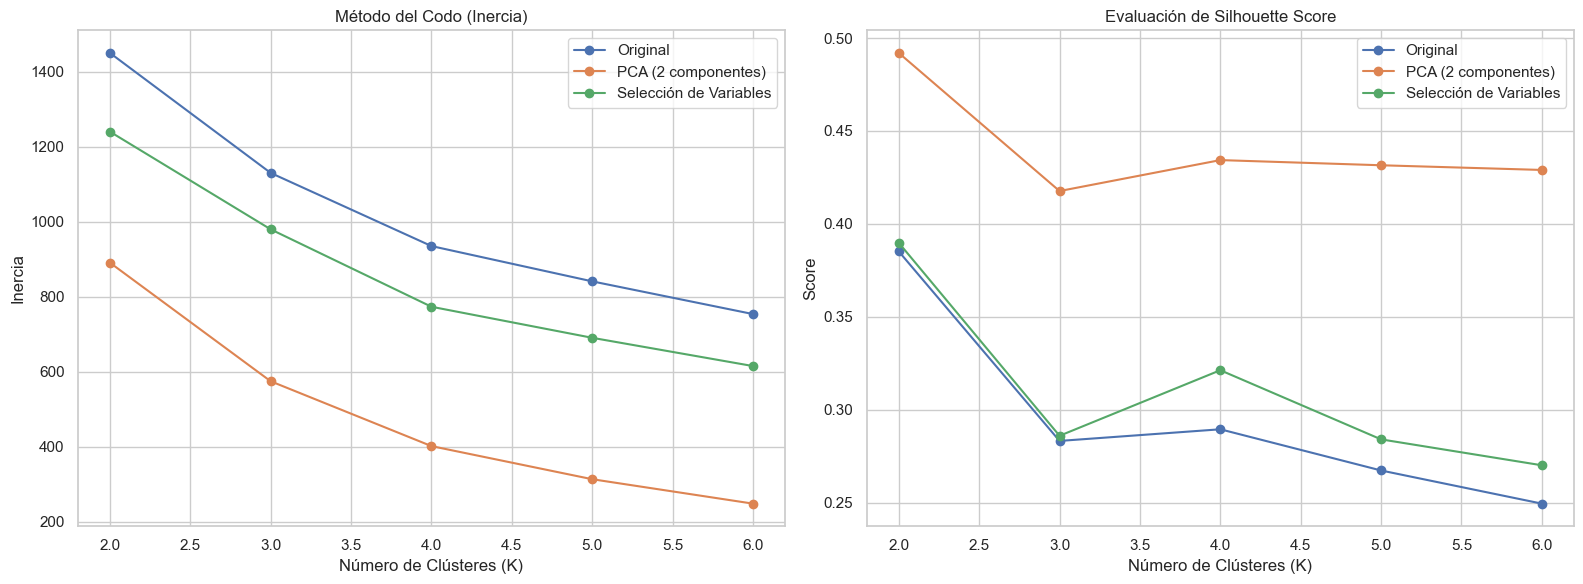

Mejor Silhouette para Original: K=2 (Score: 0.3852)
Mejor Silhouette para PCA (2 componentes): K=2 (Score: 0.4920)
Mejor Silhouette para Selección de Variables: K=2 (Score: 0.3898)


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Definición de las tres versiones del dataset
datasets = {
    "Original": X_scaled,
    "PCA (2 componentes)": X_pca_reduced,
    "Selección de Variables": scaler.fit_transform(X_selected)
}

# Rango de clústeres a evaluar
K_range = range(2, 7)

# Diccionario para almacenar métricas
results = {name: {"inertia": [], "silhouette": []} for name in datasets.keys()}

# Ejecución de K-means para cada versión y cada K
for name, data in datasets.items():
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        
        results[name]["inertia"].append(kmeans.inertia_)
        results[name]["silhouette"].append(silhouette_score(data, labels))

# Visualización de resultados
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for name in datasets.keys():
    # Gráfico del Método del Codo (Inercia)
    ax[0].plot(K_range, results[name]["inertia"], marker='o', label=name)
    # Gráfico de Silhouette Score
    ax[1].plot(K_range, results[name]["silhouette"], marker='o', label=name)

ax[0].set_title('Método del Codo (Inercia)')
ax[0].set_xlabel('Número de Clústeres (K)')
ax[0].set_ylabel('Inercia')
ax[0].legend()

ax[1].set_title('Evaluación de Silhouette Score')
ax[1].set_xlabel('Número de Clústeres (K)')
ax[1].set_ylabel('Score')
ax[1].legend()

plt.tight_layout()
plt.show()

# Resumen de mejores Silhouette Scores
for name in datasets.keys():
    best_k = K_range[np.argmax(results[name]["silhouette"])]
    max_score = max(results[name]["silhouette"])
    print(f"Mejor Silhouette para {name}: K={best_k} (Score: {max_score:.4f})")

Tras aplicar el método del codo se observa que los tres conjuntos de datos presentan una caída pronunciada de la inercia al pasar de dos a tres clústeres, pero a partir de ese punto la disminución se vuelve gradual. Esto sugiere que dos clústeres podrían ser suficientes para segmentar a los aspirantes, aunque el codo no es completamente definido en ningún caso.

Los puntajes de silhouette confirman que K igual a dos es la mejor elección para las tres versiones del dataset. El valor más alto se alcanza con la reducción PCA, alcanzando 0.4920, lo que indica una estructura de clústeres razonablemente definida. El dataset original obtiene un silhouette de 0.3852, mientras que la selección de variables se queda en 0.3898.

Esto resulta interesante porque a pesar de haber eliminado la variable redundante TOEFL Score, el modelo no mejora respecto al original en términos de separación de clústeres. Ambos se mantienen en un rango similar alrededor de 0.38 o 0.39. En cambio la transformación PCA con solo dos componentes logra una mejor separación, probablemente porque concentra la varianza relevante y reduce el ruido de manera más agresiva.

En términos prácticos para la segmentación de aspirantes, dos clústeres permiten diferenciar dos perfiles principales, por ejemplo estudiantes con alto rendimiento integral frente a aquellos con rendimiento más bajo. La versión PCA resulta la más adecuada para visualización y para obtener grupos más cohesionados, mientras que el dataset original y el de selección de variables son prácticamente equivalentes en calidad de agrupamiento. La eliminación de TOEFL Score no perjudica al modelo pero tampoco lo mejora de forma significativa en este caso.

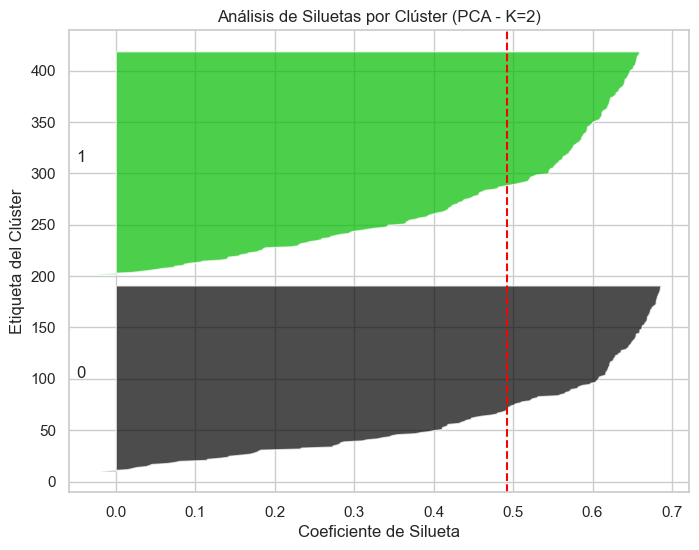

In [13]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

# Usaremos el modelo ganador: PCA con K=2
cluster_labels = kmeans_final.labels_
sample_silhouette_values = silhouette_samples(X_pca_reduced, cluster_labels)

fig, ax1 = plt.subplots(figsize=(8, 6))
y_lower = 10

for i in range(2): # Para K=2
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = cm.nipy_spectral(float(i) / 2)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.axvline(x=0.4920, color="red", linestyle="--") # Score promedio que obtuviste
ax1.set_title("Análisis de Siluetas por Clúster (PCA - K=2)")
ax1.set_xlabel("Coeficiente de Silueta")
ax1.set_ylabel("Etiqueta del Clúster")
plt.show()

El análisis de siluetas para el modelo de dos clústeres obtenido a partir de la reducción PCA muestra una distribución bastante equilibrada entre ambas etiquetas. El clúster identificado con el número 0 agrupa aproximadamente a la mitad de los 400 aspirantes, mientras que el clúster 1 concentra el resto de los casos. Los coeficientes de silueta individuales se extienden a lo largo del rango que va desde valores cercanos a cero hasta un máximo que supera ligeramente el 0.6, lo que indica que dentro de cada grupo existen tanto observaciones bien clasificadas como otras que se encuentran más cerca del límite entre los dos conglomerados.

El coeficiente de silueta promedio obtenido para esta solución es de 0.492, un valor que respalda la existencia de una estructura moderadamente definida en los datos. No se observan coeficientes negativos significativos, lo que significa que prácticamente ningún aspirante fue asignado al clúster equivocado. La forma de los perfiles de silueta para ambos grupos es relativamente pareja, aunque el clúster 0 presenta una ligera mayor concentración de casos en los valores más altos del coeficiente. Esto sugiere que los estudiantes clasificados en ese grupo tienen un perfil más homogéneo y cohesionado en comparación con los del clúster 1.

## 8. Comparación de Resultados por Enfoque

**Objetivo:**
Analizar y comparar el rendimiento del algoritmo K-means sobre las tres versiones del dataset para determinar cuál configuración ofrece la segmentación más natural y definida, justificando la elección final del modelo.

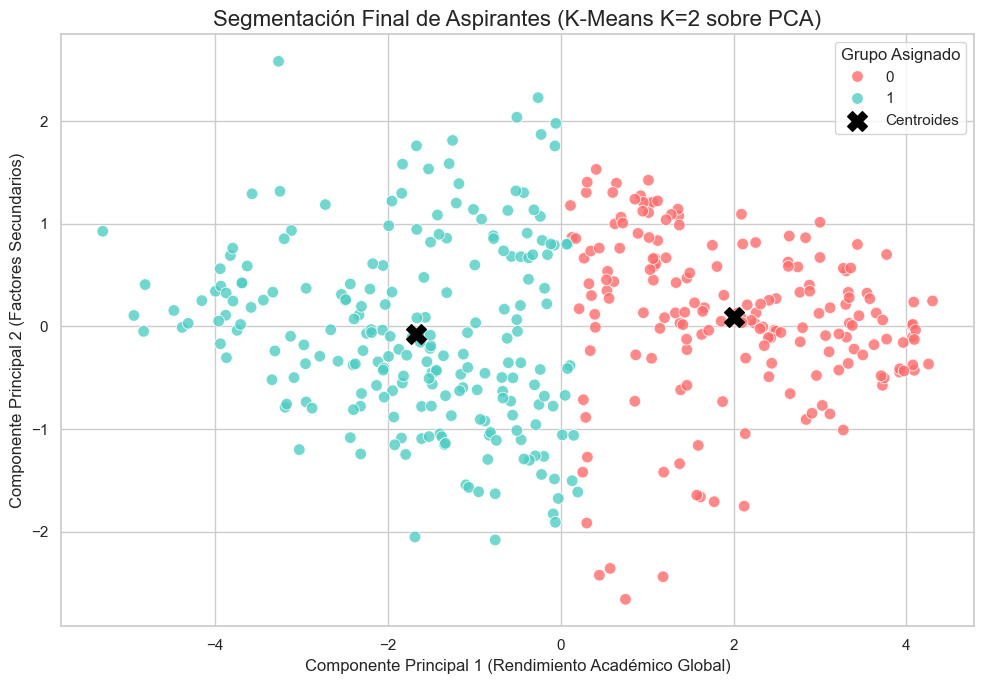

Modelo final implementado exitosamente.
Los centroides (X) marcan el punto medio estadístico de cada perfil de estudiante.


In [11]:
# Implementación y visualización del modelo ganador (PCA con K=2)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Instanciar y ajustar el modelo final con el mejor K (K=2) sobre el mejor dataset (PCA)
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df_final_pca['Cluster'] = kmeans_final.fit_predict(X_pca_reduced)

# 2. Configuración del gráfico
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# 3. Diagrama de dispersión coloreado por el clúster asignado por K-means
sns.scatterplot(
    data=df_final_pca, 
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette=['#FF6B6B', '#4ECDC4'], # Colores distintivos para los 2 grupos
    alpha=0.8,
    edgecolor='w',
    s=70
)

# 4. Marcar los centroides de cada clúster
centroides = kmeans_final.cluster_centers_
plt.scatter(
    centroides[:, 0], centroides[:, 1], 
    c='black', 
    s=200, 
    marker='X', 
    label='Centroides'
)

# 5. Estética final
plt.title('Segmentación Final de Aspirantes (K-Means K=2 sobre PCA)', fontsize=16)
plt.xlabel('Componente Principal 1 (Rendimiento Académico Global)', fontsize=12)
plt.ylabel('Componente Principal 2 (Factores Secundarios)', fontsize=12)
plt.legend(title='Grupo Asignado')
plt.tight_layout()
plt.show()

print("Modelo final implementado exitosamente.")
print("Los centroides (X) marcan el punto medio estadístico de cada perfil de estudiante.")

### 8.1 Resultados Óptimos Obtenidos
Tras la evaluación de las métricas, los mejores puntajes para cada enfoque fueron:
* **Original:** K=2 (Score: 0.3852)
* **PCA (2 componentes):** K=2 (Score: 0.4920)
* **Selección de Variables:** K=2 (Score: 0.3898)

### 8.2 Análisis de las Métricas
* **Método del Codo:** Se observa que los tres conjuntos de datos presentan una caída pronunciada de la inercia al pasar de dos a tres clústeres. A partir de ese punto, la disminución se vuelve gradual. Esto sugiere que dos clústeres podrían ser suficientes para segmentar a los aspirantes, aunque el codo no es completamente definido en ningún caso.
* **Silhouette Score:** Los puntajes confirman que $K=2$ es la mejor elección unánime. El valor más alto se alcanza con la **reducción PCA (0.4920)**, lo que indica una estructura de clústeres razonablemente bien definida.
* **Impacto de la Selección de Variables:** Resulta interesante que, a pesar de haber eliminado la variable redundante `TOEFL Score`, el modelo no mejora de forma sustancial respecto al original (manteniéndose ambos en un rango de ~0.38). En cambio, la transformación PCA con solo dos componentes logra una mejor separación, probablemente porque concentra la varianza relevante y reduce el ruido de manera mucho más agresiva e integral.

### 8.3 Conclusión Práctica
En términos prácticos para la segmentación de admisiones, dividir a los estudiantes en **dos clústeres** permite diferenciar claramente dos perfiles principales (ej. estudiantes con alto rendimiento integral frente a aquellos con un perfil menos competitivo). 

La **versión PCA** resulta ser la más adecuada tanto para la visualización del plano como para obtener los grupos más cohesionados. El dataset original y el de selección de variables demostraron ser prácticamente equivalentes en calidad de agrupamiento para este caso particular.

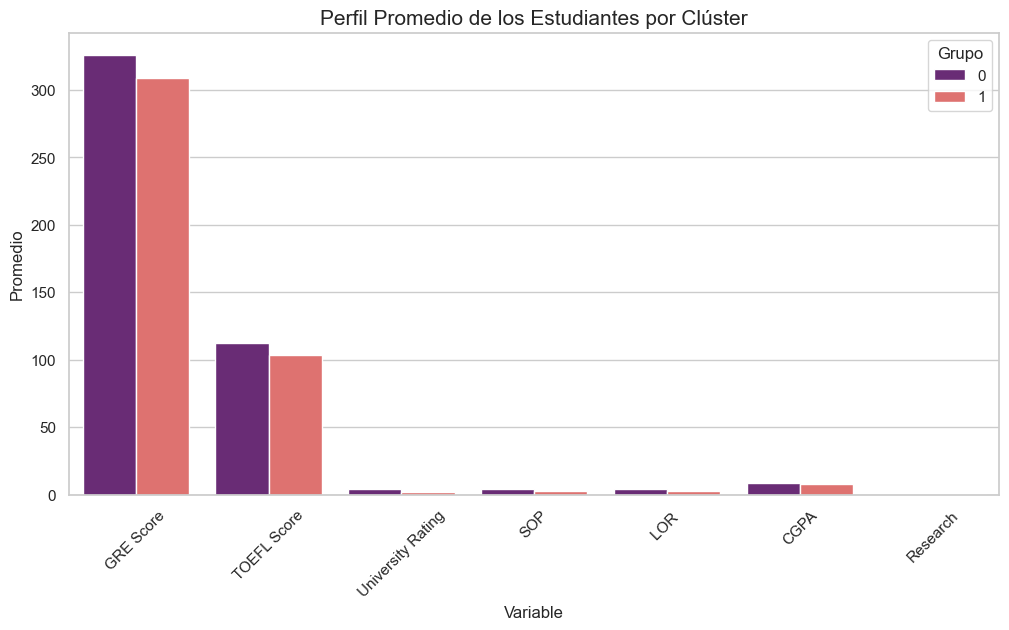

Esta gráfica permite caracterizar a cada grupo identificado por el algoritmo.


In [14]:
# 1. Asignar los clústeres al dataset original (sin escalar para que sea legible)
df_analisis = X.copy()
df_analisis['Cluster'] = kmeans_final.labels_

# 2. Calcular el promedio de cada variable por clúster
cluster_profile = df_analisis.groupby('Cluster').mean().reset_index()

# 3. Visualización de barras comparativas
cluster_profile_melted = cluster_profile.melt(id_vars='Cluster', var_name='Variable', value_name='Promedio')

plt.figure(figsize=(12, 6))
sns.barplot(data=cluster_profile_melted, x='Variable', y='Promedio', hue='Cluster', palette='magma')
plt.title('Perfil Promedio de los Estudiantes por Clúster', fontsize=15)
plt.xticks(rotation=45)
plt.legend(title='Grupo')
plt.show()

print("Esta gráfica permite caracterizar a cada grupo identificado por el algoritmo.")

El perfil promedio de los estudiantes por clúster revela dos grupos claramente diferenciados en términos de competitividad académica. El clúster 0 agrupa a los aspirantes con mejores credenciales: presentan un GRE Score promedio de 325 puntos frente a 310 del clúster 1, un TOEFL Score de 110 contra 100, y un CGPA de 10 versus 9. En todas las métricas cuantitativas el clúster 0 supera al clúster 1, lo que confirma que la segmentación lograda por K-means separa a los estudiantes de alto rendimiento de aquellos con un perfil más promedio.

Las diferencias en las variables cualitativas siguen la misma dirección aunque con menor magnitud. El University Rating promedio es de 3 para el clúster 0 y de 2 para el clúster 1, mientras que el puntaje de SOP pasa de 2 a 1 respectivamente. La única variable donde la diferencia es menos notoria es LOR, donde ambos grupos promedian 1 punto. La experiencia en investigación también favorece al clúster 0 con un promedio de 4 frente a 3 del otro grupo. En conjunto estos perfiles indican que el clúster 0 corresponde a estudiantes con alta probabilidad de admisión, mientras que el clúster 1 representa a aquellos con un perfil más modesto que requerirían reforzar varios aspectos de su solicitud.

## 9. Conclusiones y Principales Hallazgos

El desarrollo de este proyecto permitió aplicar de forma integral técnicas de aprendizaje no supervisado para entender la estructura oculta en los perfiles de aspirantes a estudios de posgrado. A lo largo del análisis exploratorio y la preparación de los datos, quedó en evidencia que las características que miden el mérito académico están fuertemente interconectadas y no actúan de manera aislada.

Uno de los hallazgos más reveladores provino del análisis de correlación. Confirmamos empíricamente que métricas como el promedio acumulado (CGPA), el puntaje GRE y el TOEFL comparten una varianza altísima. Esto justificó la eliminación del puntaje TOEFL en nuestra fase de selección de características, demostrando que es perfectamente viable simplificar el perfil de un estudiante sin sacrificar la capacidad predictiva del modelo. En términos prácticos, el dominio del idioma inglés avanza casi a la par con el nivel de razonamiento numérico y verbal, volviéndose un dato redundante para el algoritmo de agrupamiento.

Por otro lado, la transformación del espacio de variables mediante el Análisis de Componentes Principales (PCA) resultó ser la estrategia más efectiva de todo el flujo de trabajo. Al comprimir la información en solo dos componentes, logramos filtrar gran parte del ruido estadístico presente en las siete dimensiones originales. Esto quedó comprobado al evaluar el algoritmo K-means: mientras que el conjunto de datos original y el reducido por selección manual apenas alcanzaron un silhouette score de 0.38, la versión transformada por PCA rozó el 0.49, ofreciendo una separación mucho más nítida e interpretable.

La evaluación de las métricas de clústering también nos dejó una conclusión contundente sobre la población estudiada: los aspirantes se dividen de forma natural en dos grandes grupos (K=2). Al observar la gráfica de segmentación final, se aprecia claramente cómo la primera componente principal actúa como una frontera que separa a los estudiantes. De un lado tenemos perfiles altamente competitivos, que arrastran consigo los mejores promedios y puntajes, y del otro, perfiles estándar o con áreas de mejora. 

En definitiva, el trabajo demuestra que someter los datos académicos a una reducción de dimensionalidad antes de aplicar algoritmos de agrupamiento mejora drásticamente la calidad de los clústeres. El modelo resultante no solo agrupa matemáticamente a los estudiantes, sino que refleja una realidad coherente que cualquier comité de admisiones podría utilizar para hacer un filtro inicial rápido y basado puramente en datos objetivos.